## Deep Neural Network Mode (version 1)

### Part 1

##### Importing necessary libraries and constant variables


In [13]:
# custom imports
from src.utils.data_fetch import DataLoader
from src.visualisations.viz_model import plot_confusion_matrix

# for implementing neural network
import tensorflow as tf
from tensorflow import keras
import random

# other essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# various scoring metrics
from sklearn.metrics import (classification_report, accuracy_score,
                             recall_score, precision_score,
                             f1_score, roc_auc_score)

# for hyperparameter tuning
import optuna

# used for exporting the final model
# and evaluation results.
from pathlib import Path

# export path for the final logistic regression model:
project_root = Path.cwd().parent.parent.resolve()
export_dir = project_root / 'models' / 'dnn_v1'
#commented: export_dir.mkdir(parents=True, exist_ok=True)

SEED = 1234

For quickly loading data:

In [3]:
def import_data(version= None):

    if version is None:
        version = 'final_onehot'

    #loading data
    df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest = \
    DataLoader().fetch_data(version = version)

    # dropping the id columns
    id_cols = [c for c in df_Xtrain.columns if 'encounter_id' in c or 'patient_nbr' in c]
    X_train = df_Xtrain.drop(columns=id_cols)
    X_val = df_Xval.drop(columns=id_cols)
    X_test = df_Xtest.drop(columns=id_cols)

    return X_train, X_val, X_test, df_ytrain, df_yval, df_ytest

In [4]:
 X_train, X_val, X_test, y_train, y_val, y_test = import_data(version= 'final_onehot')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_test.csv 
Data imported succesfully from paths


#### Part 2 - Initial Model Creation

**2.1** Creating the model using Keras Sequential API:

For plotting the loss/auc/recall curves on training and validation sets:

In [24]:
def plot_model_report(history, kind = 'auc'):

    # plot loss, auc, recall for train and validation
    if kind not in ['auc', 'recall', 'loss']:
        raise ValueError(f"kind must be either 'loss','auc' or 'recall', not {kind}")

    if kind == 'loss':
        y_label = 'Loss'
        title = 'Loss Plot'
    elif kind == 'auc':
        y_label = 'AUC'
        title = 'AUC Plot'
    else:
        y_label = 'Recall'
        title = 'Recall Plot'

    # create the epoch range (1 to max epoch)
    epochs = np.arange(1, len(history[kind]) + 1)

    fig = plt.figure(figsize=(16, 4))
    ax = fig.add_subplot(1, 1, 1)
    # plotting Training Log Loss
    plt.plot(epochs, history[kind], lw=2, color='blue')
    # plotting Validation Log Loss
    plt.plot(epochs, history[f'val_{kind}'], lw=2, color='indianred')
    plt.legend(['Train', 'Validation'], fontsize=10)
    ax.set_xlabel('Epochs', size=10)
    ax.set_ylabel(y_label, size=10)
    ax.set_title(title)

    # show only integer epoch ticks
    # from 1 to max epoch
    ax.set_xticks(epochs)
    ax.set_xlim(1, len(history[kind]))

In [15]:
# creating the features shape:
features_shape = len(X_train.columns.tolist())

# checking the shape of the features in
# the train, validation and test sets:
assert features_shape == len(X_val.columns.tolist())
assert features_shape == len(X_test.columns.tolist())

In [29]:
def build_model(kernel_regularizer= 0.000015, lr = 0.001, drt= 0.4):

    tf.random.set_seed(1234)
    np.random.seed(1234)
    random.seed(1234)
    tf.keras.utils.set_random_seed(1234)
    tf.keras.backend.clear_session()


    # create model architecture template
    model = keras.Sequential([
        # input layer:
        keras.layers.Input(shape=(features_shape,)),
        # dense/hidden layer 1:
        keras.layers.Dense(128, use_bias= False,
                           kernel_regularizer= keras.regularizers.l2(kernel_regularizer)),
        keras.layers.BatchNormalization(), # I am using batch normalization
        keras.layers.Activation("relu"), # activation function
        keras.layers.Dropout(drt), # dropout rate

        # dense/hidden layer 2:
        keras.layers.Dense(512, use_bias= False,
                           kernel_regularizer= keras.regularizers.l2(kernel_regularizer)),
        keras.layers.BatchNormalization(), # I am using batch normalization
        keras.layers.Activation("relu"), # activation function
        keras.layers.Dropout(drt), # dropout rate

        # output layer (sigmoid function):
        keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer= keras.optimizers.Adam(learning_rate= lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"),
                 keras.metrics.Recall(name="recall")
                 ],
    )

    history = model.fit(
        X_train, y_train,
        validation_data= (X_val, y_val),
        epochs= 60,
        batch_size= 64, # 256,
        class_weight= {0: 1.0, 1: 1.3},
        callbacks= [keras.callbacks.EarlyStopping(monitor= "val_auc", # "val_auc"
                                                  mode= "max",
                                                  patience= 6, # number of epochs with no improvement after which training will be stopped
                                                  restore_best_weights= True)],
    )

    return model, history


init_model, init_history = build_model()

Epoch 1/60
932/932 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - auc: 0.6184 - loss: 0.7892 - recall: 0.6439 - val_auc: 0.6765 - val_loss: 0.6506 - val_recall: 0.6715
Epoch 2/60
932/932 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.6617 - loss: 0.7469 - recall: 0.6797 - val_auc: 0.6833 - val_loss: 0.6488 - val_recall: 0.6859
Epoch 3/60
932/932 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.6722 - loss: 0.7404 - recall: 0.6924 - val_auc: 0.6845 - val_loss: 0.6488 - val_recall: 0.6940
Epoch 4/60
932/932 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - auc: 0.6756 - loss: 0.7386 - recall: 0.6937 - val_auc: 0.6857 - val_loss: 0.6471 - val_recall: 0.6744
Epoch 5/60
932/932 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.6802 - loss: 0.7357 - recall: 0.6941 - val_auc: 0.6863 - val_loss: 0.6482 - val_recall: 0.6749
Epoch 6/60
932/932 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.6818 - loss: 0.7349 - recall: 0.6944 - val_auc: 0.6851 - val_loss: 0.6501 - val_recall: 0.6816
Epoch 7/60
932/932 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - auc: 0.686

In [30]:
init_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,229 (1.05 MB)

 Trainable params: 91,649 (358.00 KB)

 Non-trainable params: 1,280 (5.00 KB)

 Optimizer params: 183,300 (716.02 KB)

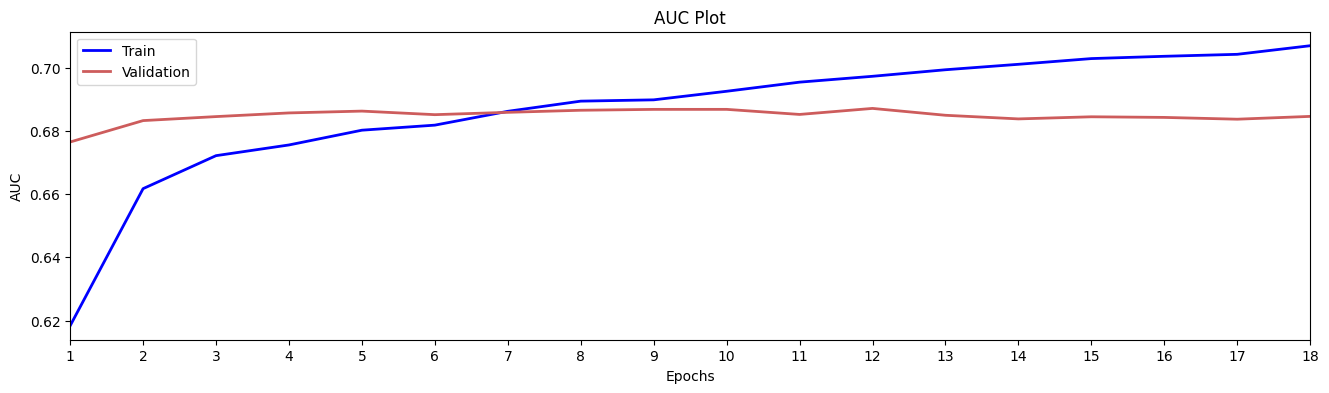

In [31]:
plot_model_report(history= init_history.history, kind= 'auc')

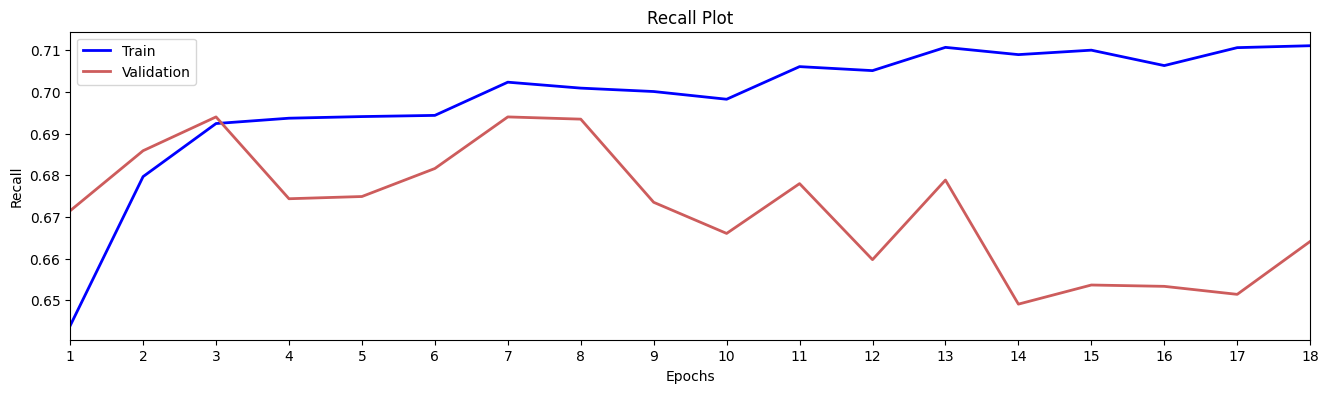

In [32]:
plot_model_report(history= init_history.history, kind= 'recall')

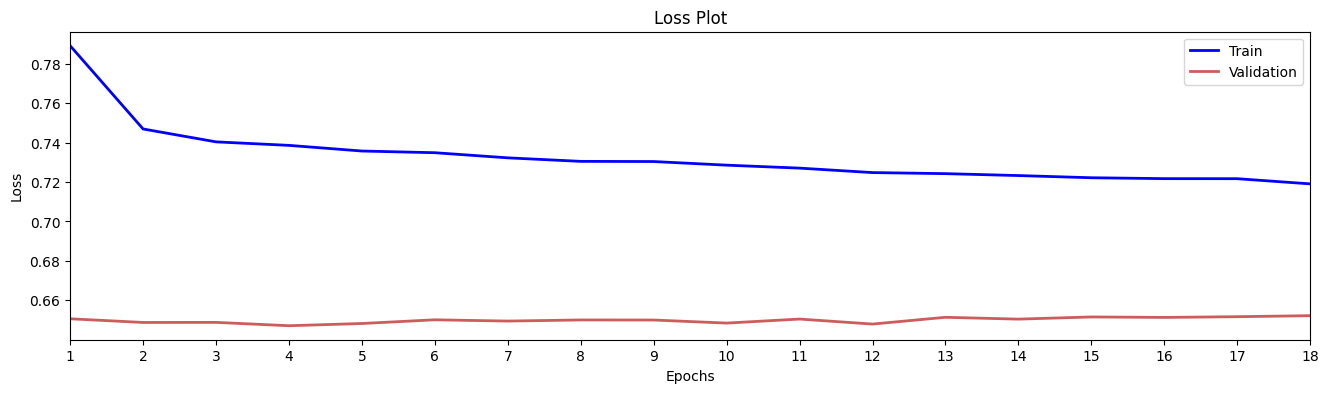

In [33]:
plot_model_report(history= init_history.history, kind= 'loss')